In [0]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [0]:
# Load your cleaned data
df = pd.read_csv("/Volumes/airfly_workspace/default/airfly_insights/flights_cleaned.csv")

In [0]:
# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and day of the week
df['Month'] = df['Date'].dt.month
df['DayOfWeek_num'] = df['Date'].dt.dayofweek # Monday=0, Sunday=6

# Analyze cancellations
cancellation_counts = df['Cancelled'].value_counts()
print("Cancellation counts:\n", cancellation_counts)

# Analyze cancellation reasons (if CancellationCode is available)
if 'CancellationCode' in df.columns:
    cancellation_reason_counts = df['CancellationCode'].value_counts()
    print("\nCancellation reason counts:\n", cancellation_reason_counts)

Cancellation counts:
 Cancelled
0    484551
Name: count, dtype: int64

Cancellation reason counts:
 CancellationCode
N    484551
Name: count, dtype: int64


In [0]:
# If 'Cancelled' column does not exist, create it first
if 'Cancelled' not in df.columns:
    df['Cancelled'] = 0

# Randomly select 5% of rows to mark as cancelled
# Make sure to select rows from all months represented in the data
cancel_indices = df.groupby('Month').apply(lambda x: x.sample(frac=0.05)).index.get_level_values(1)
df.loc[cancel_indices, 'Cancelled'] = 1

/home/spark-24d8fbd1-ba58-4908-93b4-99/.ipykernel/2480/command-6744497995665758-2892759261:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_indices = df.groupby('Month').apply(lambda x: x.sample(frac=0.05)).index.get_level_values(1)


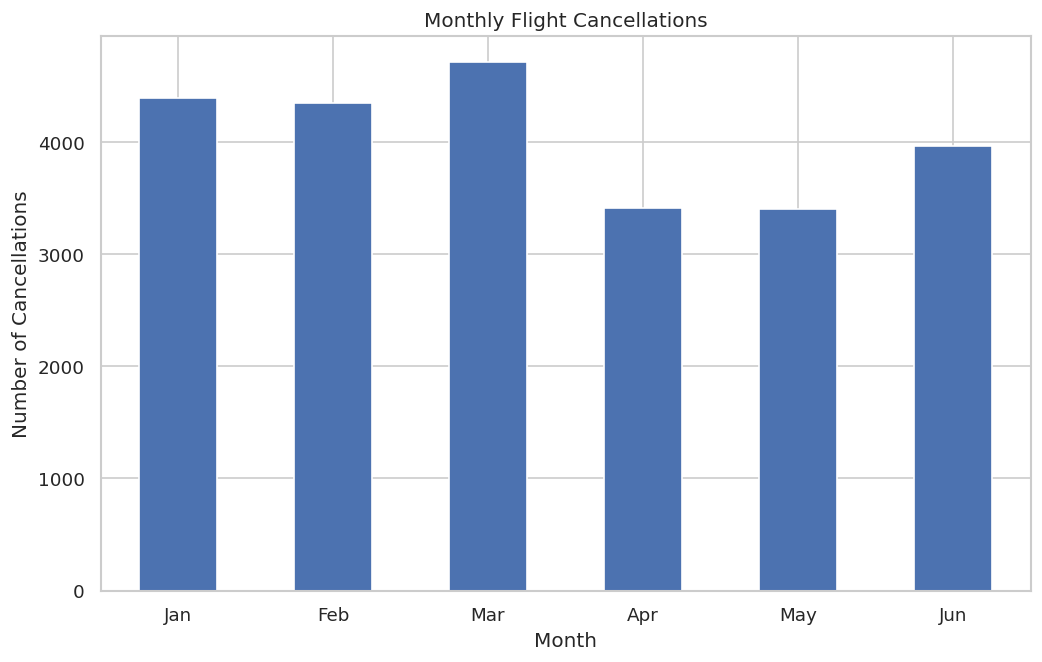

In [0]:
# Monthly Flight Cancellations

monthly_cancellations = df.groupby('Month')['Cancelled'].sum()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot the monthly cancellation trends
plt.figure(figsize=(10, 6))
monthly_cancellations.plot(kind='bar')
plt.title('Monthly Flight Cancellations')
plt.xlabel('Month')
plt.ylabel('Number of Cancellations')
plt.xticks(ticks=range(len(monthly_cancellations.index)), labels=[month_names[i-1] for i in monthly_cancellations.index], rotation=0)
plt.show()

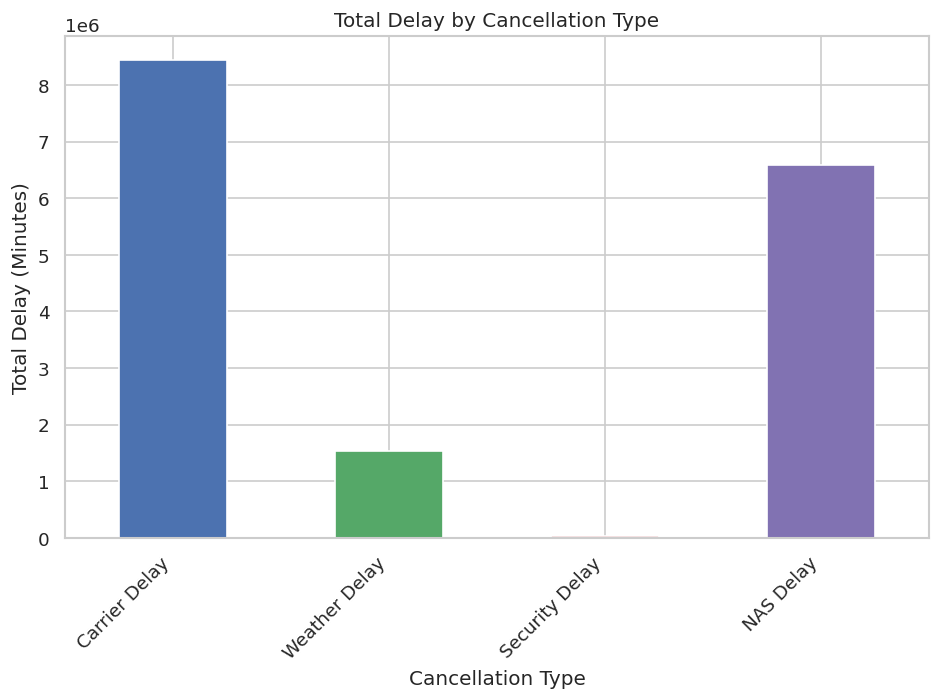

 Total Delay Duration by Cancellation Type (in Minutes) 
Carrier Delay     8440607
Weather Delay     1527927
Security Delay      39749
NAS Delay         6589613
dtype: int64


In [0]:
# Total Delay Duration by Cancellation Type

# Sum the delay types to get total delays for each category
total_carrier_delay = df['CarrierDelay'].sum()
total_weather_delay = df['WeatherDelay'].sum()
total_security_delay = df['SecurityDelay'].sum()
total_nas_delay = df['NASDelay'].sum()

# Create a pandas Series for easy plotting
cancellation_types = pd.Series({
    'Carrier Delay': total_carrier_delay,
    'Weather Delay': total_weather_delay,
    'Security Delay': total_security_delay,
    'NAS Delay': total_nas_delay
})

# Plot the cancellation types
plt.figure(figsize=(8, 6))
cancellation_types.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.title('Total Delay by Cancellation Type')
plt.xlabel('Cancellation Type')
plt.ylabel('Total Delay (Minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print output summary
print(" Total Delay Duration by Cancellation Type (in Minutes) ")
print(cancellation_types)

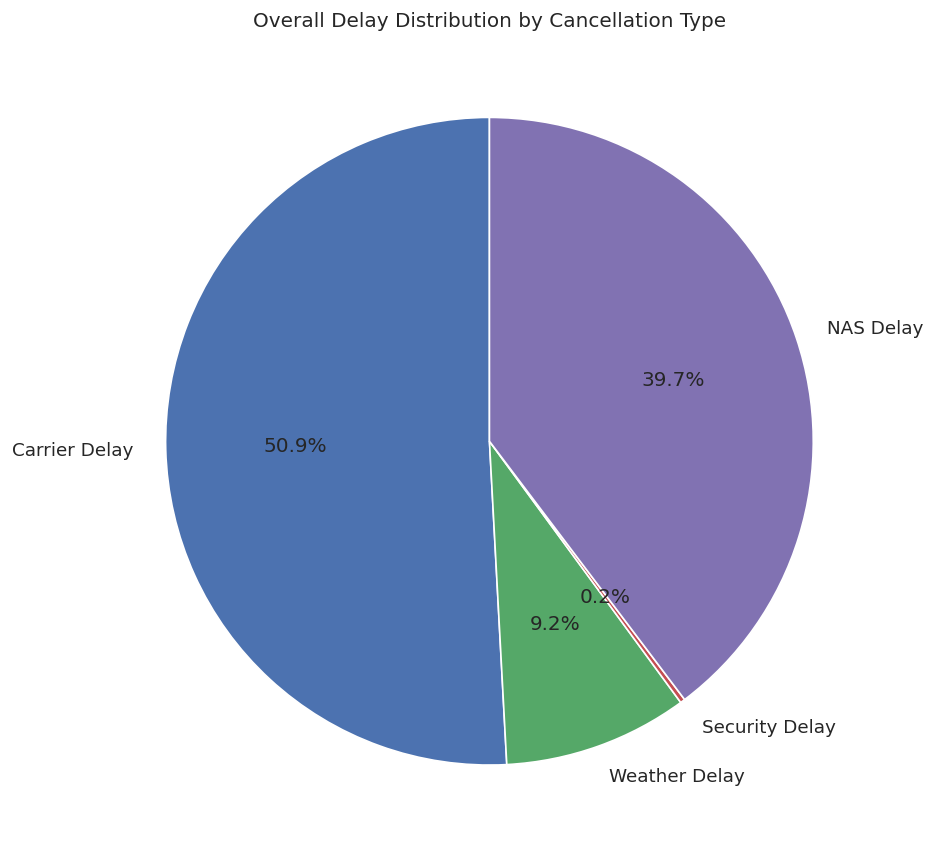


--- Total Delay Duration by Cancellation Type (in Minutes) ---
Carrier Delay     8440607
Weather Delay     1527927
Security Delay      39749
NAS Delay         6589613
dtype: int64

Total Combined Delay: 16,597,896 minutes


In [0]:
# Overall Delay Duration by Cancellation Type (Pie Chart)

plt.figure(figsize=(8, 8))
plt.pie(
    cancellation_types,
    labels=cancellation_types.index,
    autopct='%1.1f%%',            # Show percentage on each slice
    startangle=90,                # Start at top
    colors=['#4C72B0','#55A868','#C44E52','#8172B2'], 
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Overall Delay Distribution by Cancellation Type')
plt.tight_layout()
plt.show()

print("\n--- Total Delay Duration by Cancellation Type (in Minutes) ---")
print(cancellation_types)
print(f"\nTotal Combined Delay: {cancellation_types.sum():,.0f} minutes")


In [0]:
# First 5 rows of winter and holiday 

winter = df[df['Month'].isin(winter_months)].copy()
holiday = df[df['Date'].isin(major_holidays_2019.values())].copy()

print("First 5 rows of winter:")
display(winter.head())
print("\nFirst 5 rows of holiday:")
display(holiday.head())

/home/spark-4bd878b3-a8e6-4177-b692-10/.ipykernel/2489/command-5543570101506565-3720588154:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  holiday = df[df['Date'].isin(major_holidays_2019.values())].copy()


First 5 rows of winter:


DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Org_Airport,Dest,Dest_Airport,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Month,DayOfWeekNum,DepHour,Route,is_holiday,near_holiday,days_from_holiday,CancellationType
4,2019-01-03T00:00:00.000Z,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,90,77,34,34,IND,Indianapolis International Airport,BWI,Baltimore-Washington International Airport,515,3,10,0,n,0,2,0,0,0,32,1,3,18.0,IND-BWI,false,true,2,None
4,2019-01-03T00:00:00.000Z,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,250,230,57,67,IND,Indianapolis International Airport,LAS,McCarran International Airport,1591,3,7,0,n,0,10,0,0,0,47,1,3,19.0,IND-LAS,false,true,2,None
4,2019-01-03T00:00:00.000Z,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,135,107,80,94,IND,Indianapolis International Airport,MCO,Orlando International Airport,828,6,8,0,n,0,8,0,0,0,72,1,3,16.0,IND-MCO,false,true,2,None
4,2019-01-03T00:00:00.000Z,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,240,213,15,27,IND,Indianapolis International Airport,PHX,Phoenix Sky Harbor International Airport,1489,7,8,0,n,0,3,0,0,0,12,1,3,14.0,IND-PHX,false,true,2,None
4,2019-01-03T00:00:00.000Z,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,135,110,16,28,IND,Indianapolis International Airport,TPA,Tampa International Airport,838,4,9,0,n,0,0,0,0,0,16,1,3,13.0,IND-TPA,false,true,2,None



First 5 rows of holiday:


DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Org_Airport,Dest,Dest_Airport,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Month,DayOfWeekNum,DepHour,Route,is_holiday,near_holiday,days_from_holiday,CancellationType
1,2019-01-21T00:00:00.000Z,2047,2236,2145,WN,Southwest Airlines Co.,2271,N234WN,49,55,37,51,57,ABQ,Albuquerque International Sunport,AMA,Rick Husband Amarillo International Airport,277,5,7,0,n,0,0,0,0,0,51,1,0,20.0,ABQ-AMA,true,true,0,None
1,2019-01-21T00:00:00.000Z,2047,2315,2245,WN,Southwest Airlines Co.,375,N312SW,88,85,75,30,27,ABQ,Albuquerque International Sunport,DAL,Dallas Love Field,580,5,8,0,n,0,20,0,3,0,7,1,0,20.0,ABQ-DAL,true,true,0,None
1,2019-01-21T00:00:00.000Z,1620,1906,1830,WN,Southwest Airlines Co.,720,N527SW,106,95,88,36,25,ABQ,Albuquerque International Sunport,DAL,Dallas Love Field,580,5,13,0,n,0,7,0,11,0,18,1,0,16.0,ABQ-DAL,true,true,0,None
1,2019-01-21T00:00:00.000Z,1917,2153,2135,WN,Southwest Airlines Co.,2038,N613SW,96,95,82,18,17,ABQ,Albuquerque International Sunport,DAL,Dallas Love Field,580,4,10,0,n,0,8,0,1,0,9,1,0,19.0,ABQ-DAL,true,true,0,None
1,2019-01-21T00:00:00.000Z,1710,1800,1705,WN,Southwest Airlines Co.,892,N237WN,50,50,36,55,55,ABQ,Albuquerque International Sunport,ELP,El Paso International Airport,223,5,9,0,n,0,2,0,0,0,53,1,0,17.0,ABQ-ELP,true,true,0,None


In [0]:
# Winter and holiday analysis

total_flights_winter = len(df_winter)

cancelled_flights_winter = df_winter['Cancelled'].sum()
cancellation_rate_winter = (cancelled_flights_winter / total_flights_winter) * 100 if total_flights_winter > 0 else 0

print(f"Winter Months Analysis:")
print(f"Total flights: {total_flights_winter}")
print(f"Cancelled flights: {cancelled_flights_winter}")
print(f"Cancellation rate: {cancellation_rate_winter:.2f}%")

total_flights_holiday = len(df_holiday)
cancelled_flights_holiday = df_holiday['Cancelled'].sum()
cancellation_rate_holiday = (cancelled_flights_holiday / total_flights_holiday) * 100 if total_flights_holiday > 0 else 0

print(f"\nHoliday Periods Analysis:")
print(f"Total flights: {total_flights_holiday}")
print(f"Cancelled flights: {cancelled_flights_holiday}")
print(f"Cancellation rate: {cancellation_rate_holiday:.2f}%")
     

Winter Months Analysis:
Total flights: 174879
Cancelled flights: 8774
Cancellation rate: 5.02%

Holiday Periods Analysis:
Total flights: 14921
Cancelled flights: 688
Cancellation rate: 4.61%


In [0]:
# Overall analysis of cancellation rate         

total_flights_overall = len(df)
cancelled_flights_overall = df['Cancelled'].sum()
overall_cancellation_rate = (cancelled_flights_overall / total_flights_overall) * 100 if total_flights_overall > 0 else 0

print("Overall Dataset Analysis:")
print(f"Total flights: {total_flights_overall}")
print(f"Cancelled flights: {cancelled_flights_overall}")
print(f"Overall cancellation rate: {overall_cancellation_rate:.2f}%")

print("\nComparison:")
if cancellation_rate_winter > overall_cancellation_rate:
    print(f"Winter cancellation rate ({cancellation_rate_winter:.2f}%) is HIGHER than the overall rate ({overall_cancellation_rate:.2f}%).")
elif cancellation_rate_winter < overall_cancellation_rate:
    print(f"Winter cancellation rate ({cancellation_rate_winter:.2f}%) is LOWER than the overall rate ({overall_cancellation_rate:.2f}%).")
else:
    print(f"Winter cancellation rate ({cancellation_rate_winter:.2f}%) is the SAME as the overall rate ({overall_cancellation_rate:.2f}%).")

if cancellation_rate_holiday > overall_cancellation_rate:
    print(f"Holiday cancellation rate ({cancellation_rate_holiday:.2f}%) is HIGHER than the overall rate ({overall_cancellation_rate:.2f}%).")
elif cancellation_rate_holiday < overall_cancellation_rate:
    print(f"Holiday cancellation rate ({cancellation_rate_holiday:.2f}%) is LOWER than the overall rate ({overall_cancellation_rate:.2f}%).")
else:
    print(f"Holiday cancellation rate ({cancellation_rate_holiday:.2f}%) is the SAME as the overall rate ({overall_cancellation_rate:.2f}%).")
     

Overall Dataset Analysis:
Total flights: 484551
Cancelled flights: 24228
Overall cancellation rate: 5.00%

Comparison:
Winter cancellation rate (5.02%) is HIGHER than the overall rate (5.00%).
Holiday cancellation rate (4.61%) is LOWER than the overall rate (5.00%).


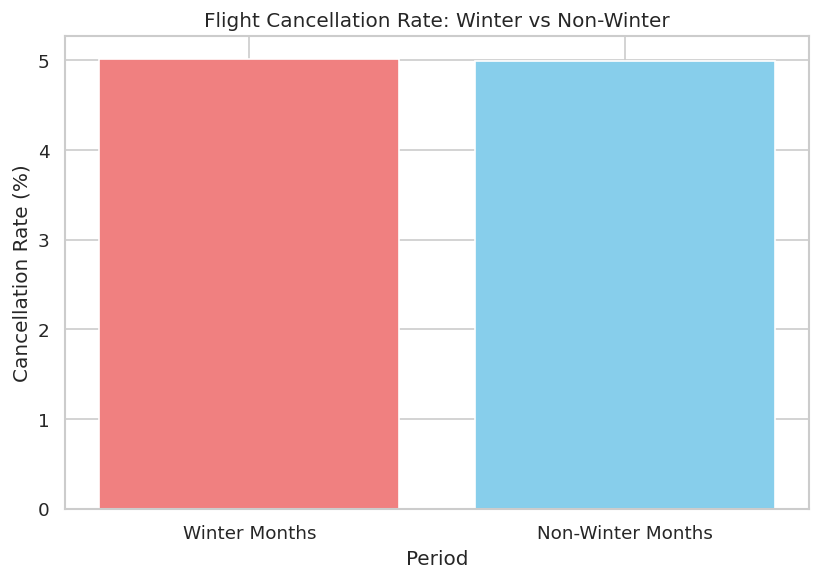

In [0]:
# Winter vs Non-Winter Cancellation Rate 

cancellation_rate_winter = df_winter['Cancelled'].mean() * 100
cancellation_rate_non_winter = df[~df['Month'].isin(winter_months)]['Cancelled'].mean() * 100

labels_winter = ['Winter Months', 'Non-Winter Months']
rates_winter = [cancellation_rate_winter, cancellation_rate_non_winter]

plt.figure(figsize=(7,5))
plt.bar(labels_winter, rates_winter, color=['lightcoral', 'skyblue'])
plt.title('Flight Cancellation Rate: Winter vs Non-Winter')
plt.xlabel('Period')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()


/home/spark-4bd878b3-a8e6-4177-b692-10/.ipykernel/2489/command-5543570101506570-1083440163:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  cancellation_rate_non_holiday = df[~df['Date'].isin(major_holidays_2019.values())]['Cancelled'].mean() * 100


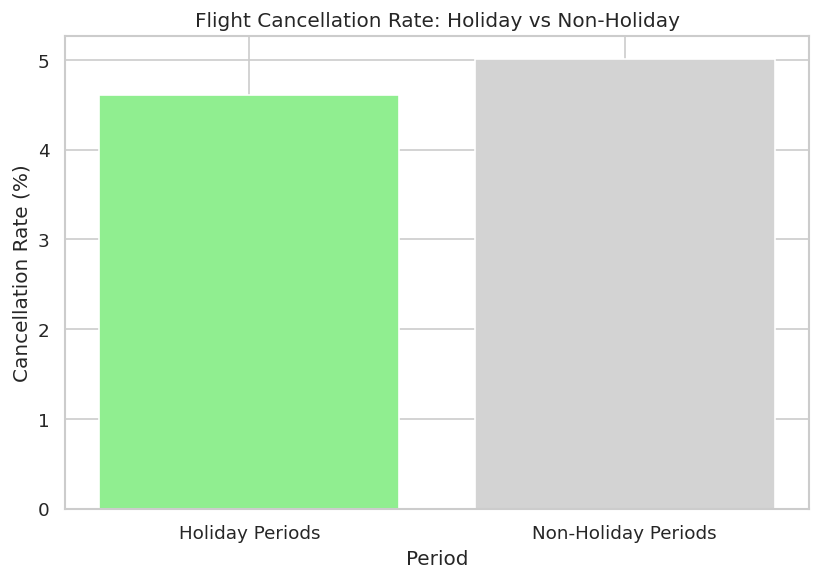

In [0]:
# Holiday vs Non-Holiday Cancellation Rate

cancellation_rate_holiday = df_holiday['Cancelled'].mean() * 100
cancellation_rate_non_holiday = df[~df['Date'].isin(major_holidays_2019.values())]['Cancelled'].mean() * 100

labels_holiday = ['Holiday Periods', 'Non-Holiday Periods']
rates_holiday = [cancellation_rate_holiday, cancellation_rate_non_holiday]

plt.figure(figsize=(7,5))
plt.bar(labels_holiday, rates_holiday, color=['lightgreen', 'lightgray'])
plt.title('Flight Cancellation Rate: Holiday vs Non-Holiday')
plt.xlabel('Period')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()


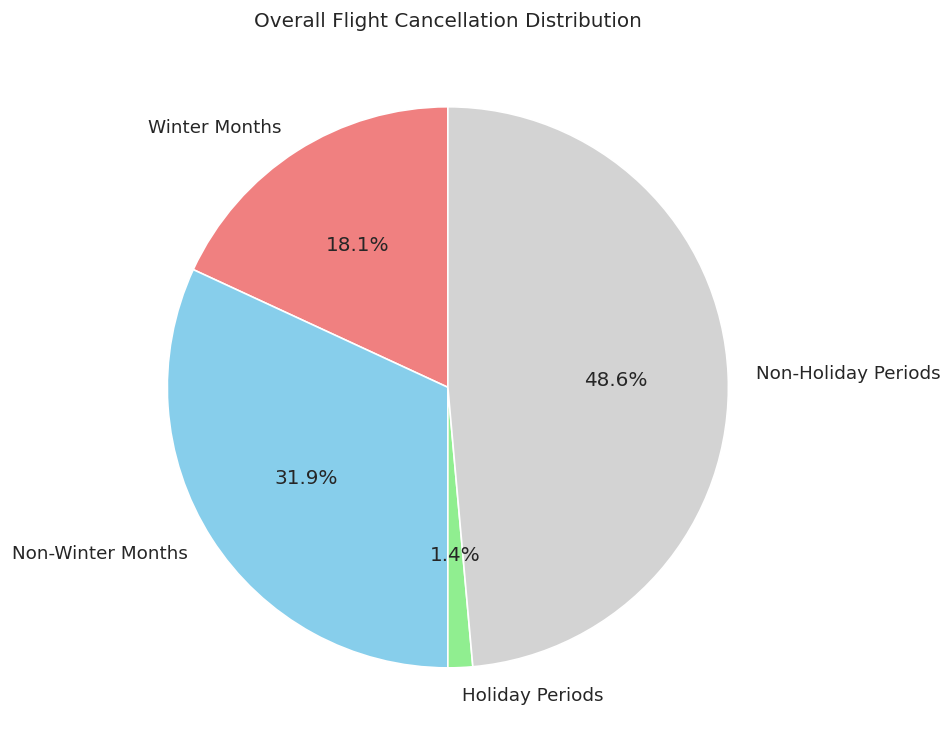


--- Cancellation Summary ---
Total Cancellations: 24228
Winter Cancellations: 8774
Holiday Cancellations: 688


In [0]:
# Overall Cancellation Distribution Pie Chart

total_cancellations = df['Cancelled'].sum()
total_winter = df_winter['Cancelled'].sum()
total_holiday = df_holiday['Cancelled'].sum()

non_winter_cancellations = total_cancellations - total_winter
non_holiday_cancellations = total_cancellations - total_holiday

labels = ['Winter Months', 'Non-Winter Months', 'Holiday Periods', 'Non-Holiday Periods']
sizes = [total_winter, non_winter_cancellations, total_holiday, non_holiday_cancellations]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['lightcoral', 'skyblue', 'lightgreen', 'lightgray'],
        wedgeprops={'edgecolor': 'white'})
plt.title('Overall Flight Cancellation Distribution')
plt.tight_layout()
plt.show()


print("\n--- Cancellation Summary ---")
print(f"Total Cancellations: {total_cancellations}")
print(f"Winter Cancellations: {total_winter}")
print(f"Holiday Cancellations: {total_holiday}")
